# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import axes


# Load data

In [2]:
games_odds = pd.read_csv("data/game_odds.csv")


In [3]:
games_index = pd.read_csv("data/games_index.csv")

In [4]:
games_schedule = pd.read_csv("data/games_schedule.csv")

In [5]:
play_by_play = pd.read_csv("data/play_by_play.csv")

In [6]:
player_boxscores = pd.read_csv("data/player_boxscores.csv")

In [7]:
team_boxscores = pd.read_csv("data/team_boxscores.csv")

# Clean data

In [8]:
#get rid of nan values in the datasets
games_odds = games_odds.dropna()
games_index = games_index.dropna()
games_schedule = games_schedule.dropna()

#play_by_play = play_by_play.dropna() # don't drop because it'll drop every row that's not a shoot, because the subtype column is "Unknown" for every action that's not a shoot, and we need to keep those actions to be able to analyze the best players
#insted : drop rows where player_name_i is nan
play_by_play = play_by_play.dropna(subset=['player_name_i'])

player_boxscores = player_boxscores.dropna()
team_boxscores = team_boxscores.dropna()

# See data

In [9]:
#get all action types ranked by number of occurences in the play_by_play dataset
action_types_count = play_by_play['action_type'].value_counts().reset_index()
action_types_count.columns = ['action_type', 'count']
print("Action types ranked by number of occurences:")
display(action_types_count)

Action types ranked by number of occurences:


,action_type,count
0,Missed Shot,3438391
1,Rebound,3234950
2,Made Shot,2876493
3,Free Throw,1814447
4,Foul,1630059
5,Substitution,1587219
6,Turnover,1045872
7,Jump Ball,66367
8,Violation,50288
9,Instant Replay,13865


In [10]:
play_by_play_columns = ['game_id', 'game_date', 'game_matchup', 'team_id', 'person_id',
       'action_id', 'action_number', 'clock', 'period', 'team_tri_code',
       'player_name', 'player_name_i', 'xlegacy', 'ylegacy', 'shot_distance',
       'shot_result', 'is_field_goal', 'score_home', 'score_away',
       'points_total', 'location', 'description', 'action_type', 'subtype',
       'video_available', 'shot_value']

# Players analysis

## Player infos (full name, abreviate name, team abreviation, season year) in one place : get by functions

In [11]:
# new column little_name : LeBron James -> L. James in player_boxscores dataset
player_boxscores["little_name"] = player_boxscores["player_name"].apply(lambda x: x[0] + ". " + x.split(" ")[-1])

# aggregate player_boxscores to get the player_id, player_name, little_name, team_abbreviation and season_year for each player_id
player_simple_infos = (
    player_boxscores
    .groupby(
        ["season_year", "team_abbreviation", "player_id"],
        as_index=False
    )
    .agg({
        "player_name": "first",
        "little_name": "first",
    })
)

#-display(player_simple_infos.head())

def get_player_full_name(player_id):
    player_info = player_simple_infos[player_simple_infos["player_id"] == player_id]
    if not player_info.empty:
        return player_info["player_name"].values[0]
    else:
        return None
def get_player_little_name(player_id):
    player_info = player_simple_infos[player_simple_infos["player_id"] == player_id]
    if not player_info.empty:
        return player_info["little_name"].values[0]
    else:
        return None

#display all the rows where the little_name is L. James
l_james_rows = player_simple_infos[player_simple_infos["little_name"] == "L. James"]
print("Rows where little_name is L. James:")
display(l_james_rows)

C:\Users\Carol\AppData\Local\Temp\ipykernel_22416\3676666360.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_boxscores["little_name"] = player_boxscores["player_name"].apply(lambda x: x[0] + ". " + x.split(" ")[-1])


Rows where little_name is L. James:


,season_year,team_abbreviation,player_id,player_name,little_name
272,2012-13,MIA,2544,LeBron James,L. James
803,2013-14,MIA,2544,LeBron James,L. James
1165,2014-15,CLE,2544,LeBron James,L. James
1734,2015-16,CLE,2544,LeBron James,L. James
2275,2016-17,CLE,2544,LeBron James,L. James
2823,2017-18,CLE,2544,LeBron James,L. James
3590,2018-19,LAL,2544,LeBron James,L. James
4207,2019-20,LAL,2544,LeBron James,L. James
4821,2020-21,LAL,2544,LeBron James,L. James
5473,2021-22,LAL,2544,LeBron James,L. James


## Player_boxscores

### preparation : dict for column names + aggregate

In [12]:
stat_columns_player_boxscores = {
        "pts":   "points",
        "reb":   "rebounds",
        "ast":   "assists",
        "stl":   "steals",
        "blk":   "blocks",
        "tov":   "turnovers",
        "min":   "minutes",
        "fgm":   "Field Goals Made",
        "fga":   "Field Goals Attempted",
        "fg3m":  "Three Pointers Made",
        "fg3a":  "Three Pointers Attempted",
        "ftm":   "Free Throws Made",
        "fta":   "Free Throws Attempted",
        "plus_minus": "impact of player on team performance",
        "dreb":  "defensive rebounds",
        "oreb":  "offensive rebounds",
    }
available = {k: v for k, v in stat_columns_player_boxscores.items() if k in player_boxscores.columns}
player_wins_per_team = (
        player_boxscores.groupby(["player_id", "player_name", "team_abbreviation"], as_index=False)
          .agg(
              games=("game_id", "nunique"),
              **{v: (k, "mean") for k, v in available.items()}
          )
    )
# print("Aggregated Player Stats:")
# display(player_wins_per_team)

### Player_boxscores get top_players_points_avg, top_player_rebounds, top_player_assists

In [ ]:
# Plotting average points per game for top 20 players
top_players_points_avg = player_wins_per_team.sort_values(by="points", ascending=False).head(20).copy()
top_players_points_avg["little_name"] = top_players_points_avg["player_id"].apply(get_player_little_name)

#print(top_players_points_avg[["player_name", "points", "team_abbreviation"]])

top_player_rebounds_avg = player_wins_per_team.sort_values(by="rebounds", ascending=False).head(20).copy()
top_player_assists_avg = player_wins_per_team.sort_values(by="assists", ascending=False).head(20).copy()

# add little_name column without relying on index labels
top_player_rebounds_avg["little_name"] = top_player_rebounds_avg["player_id"].apply(get_player_little_name)
top_player_assists_avg["little_name"] = top_player_assists_avg["player_id"].apply(get_player_little_name)


,player_id,player_name,team_abbreviation,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
707,201566,Russell Westbrook,WAS,72,21.916667,11.444444,11.694444,1.319444,0.361111,4.722222,36.457824,8.111111,18.791667,1.263889,4.138889,4.430556,6.569444,-1.902778,9.652778,1.791667
499,200765,Rajon Rondo,SAC,72,11.930556,6.041667,11.652778,1.958333,0.138889,3.861111,35.231782,4.930556,10.861111,0.861111,2.361111,1.208333,2.083333,-2.138889,4.972222,1.069444
492,200765,Rajon Rondo,BOS,90,11.711111,6.011111,10.566667,1.633333,0.155556,3.577778,34.671537,4.966667,11.277778,0.511111,1.911111,1.266667,2.177778,-2.744444,5.011111,1.000000
869,201935,James Harden,BKN,89,23.112360,8.033708,10.292135,1.314607,0.719101,4.280899,36.716348,7.022472,15.876404,2.494382,7.134831,6.573034,7.584270,2.460674,7.146067,0.887640
873,201935,James Harden,PHI,102,20.627451,6.264706,10.117647,1.235294,0.470588,3.450980,37.579853,6.098039,14.401961,2.607843,7.029412,5.823529,6.637255,3.960784,5.578431,0.686275


### Plot data : avg points per game, avg points + avg rebounds + avg assists per game

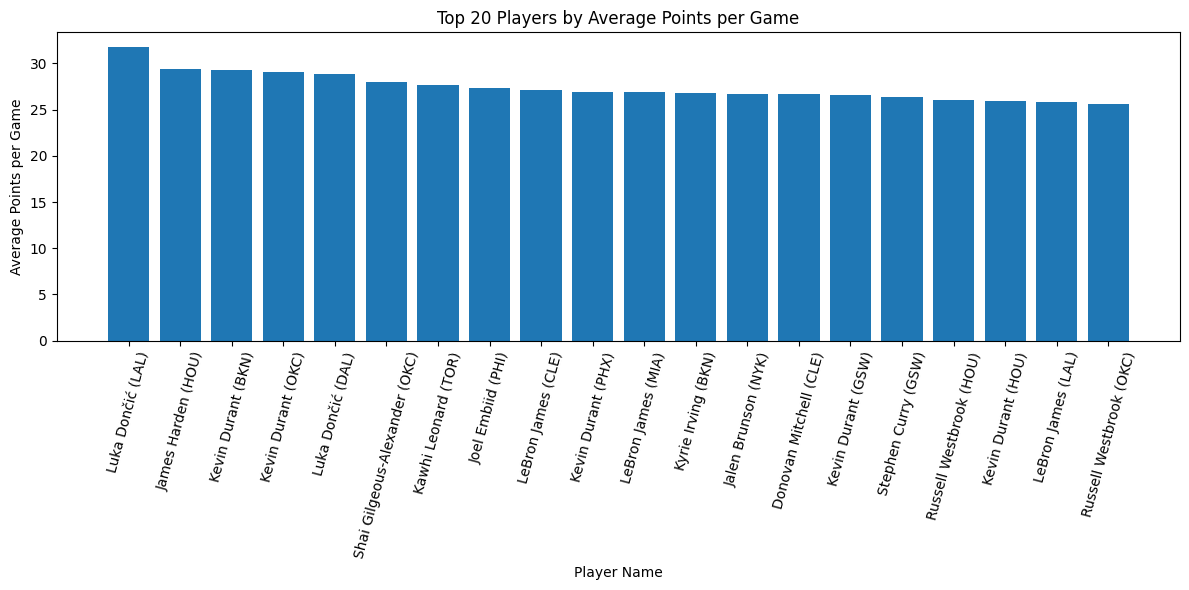

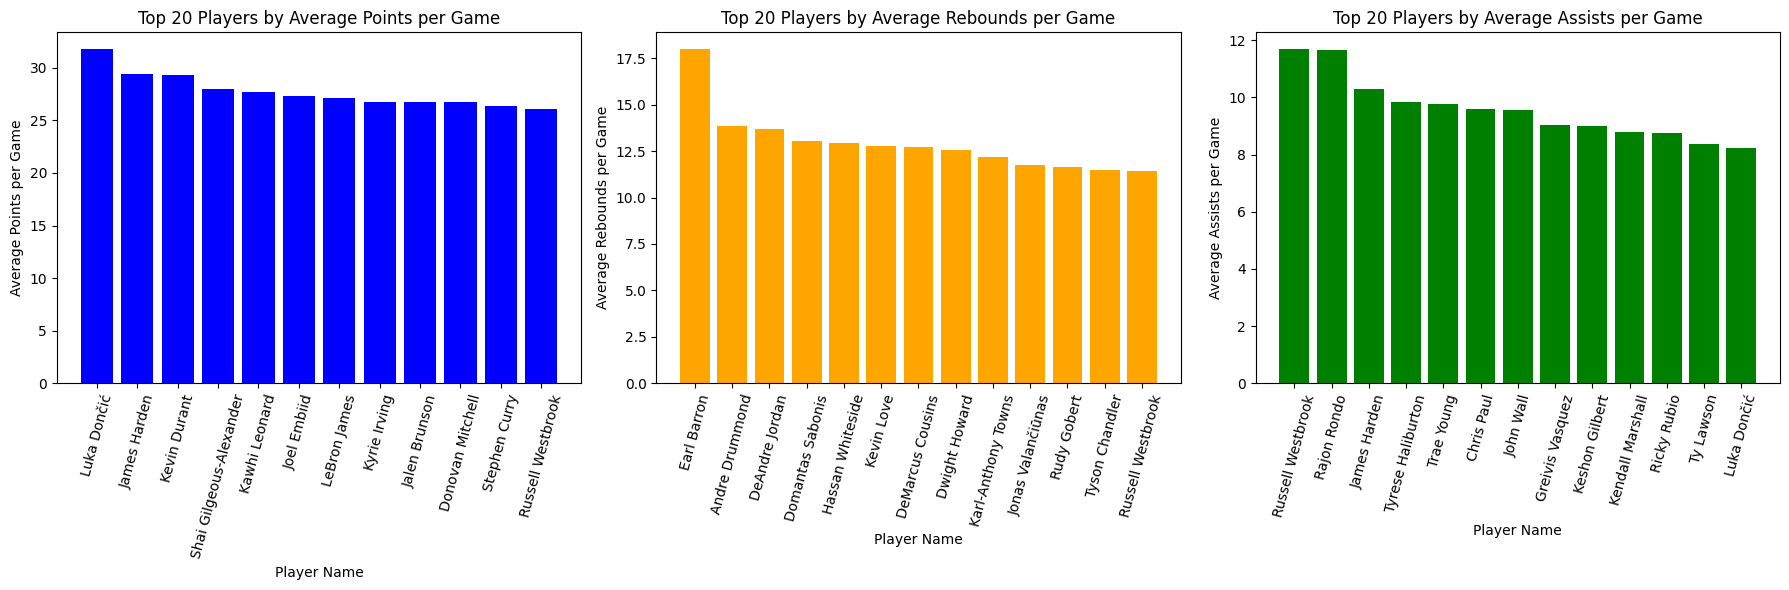

In [14]:
# Plotting average points per game for top 10 players without taking into account the team they played for
plt.figure(figsize=(12, 6))
plt.bar(top_players_points_avg["player_name"] + " (" + top_players_points_avg["team_abbreviation"] + ")", top_players_points_avg["points"])
plt.xlabel("Player Name")
plt.ylabel("Average Points per Game")
plt.title("Top 20 Players by Average Points per Game")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# plot better players by points, rebounds and assists
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].bar(top_players_points_avg["player_name"], top_players_points_avg["points"], color='blue')
axes[0].set_xlabel("Player Name")
axes[0].set_ylabel("Average Points per Game")
axes[0].set_title("Top 20 Players by Average Points per Game")
axes[0].tick_params(axis='x', rotation=75)
axes[1].bar(top_player_rebounds_avg["player_name"], top_player_rebounds_avg["rebounds"], color='orange')
axes[1].set_xlabel("Player Name")
axes[1].set_ylabel("Average Rebounds per Game")
axes[1].set_title("Top 20 Players by Average Rebounds per Game")
axes[1].tick_params(axis='x', rotation=75)
axes[2].bar(top_player_assists_avg["player_name"], top_player_assists_avg["assists"], color='green')
axes[2].set_xlabel("Player Name")
axes[2].set_ylabel("Average Assists per Game")
axes[2].set_title("Top 20 Players by Average Assists per Game")
axes[2].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()



### Player by team and season

In [15]:
# # print player name, team abreviation, season from player_boxscores dataset
# print("Player name, team abreviation, season from player_boxscores dataset:")
# display(player_boxscores[['player_name', 'team_abbreviation', 'season']].head())

### Best Shooter (points + nb of shoots made) (shoot made = panier marqué)

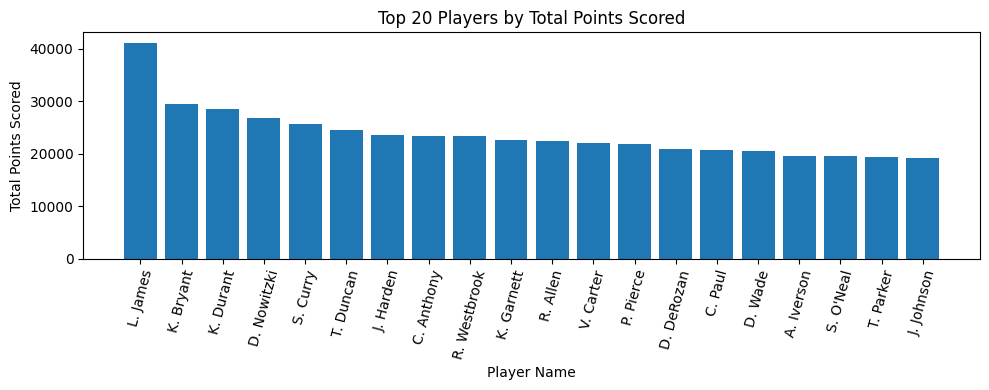

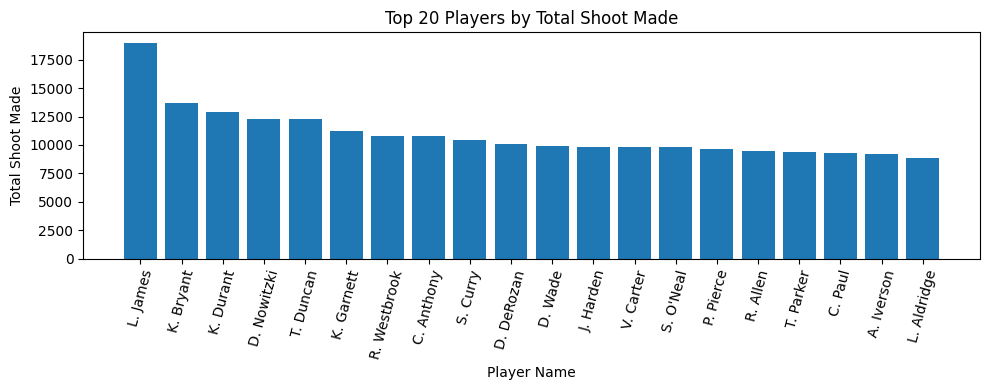

In [16]:
all_shoots_made = play_by_play[play_by_play['shot_result'] == 'Made']

# all points scored by each player in the dataset
player_points_total = all_shoots_made.groupby(["player_name_i", "person_id"], as_index=False)["shot_value"].sum().reset_index()
player_points_total = player_points_total.sort_values(by="shot_value", ascending=False)


#plotting the top 20 players by total points scored in the dataset
plt.figure(figsize=(10, 4))
plt.bar(player_points_total["player_name_i"].head(20), player_points_total["shot_value"].head(20))
plt.xlabel("Player Name")
plt.ylabel("Total Points Scored")
plt.title("Top 20 Players by Total Points Scored")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# nb of shoot made by each player in the dataset
player_shoot_made = all_shoots_made.groupby(["player_name_i", "person_id"], as_index=False)["shot_value"].count().reset_index()
player_shoot_made = player_shoot_made.sort_values(by="shot_value", ascending=False)


plt.figure(figsize=(10, 4))
plt.bar(player_shoot_made["player_name_i"].head(20), player_shoot_made["shot_value"].head(20))
plt.xlabel("Player Name")
plt.ylabel("Total Shoot Made")
plt.title("Top 20 Players by Total Shoot Made")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()




In [17]:
# check if a player is in the player_shoot_made and top_players_points_avg
best_shooter_players = set(player_shoot_made["player_name_i"].head(20)).intersection(set(top_players_points_avg["little_name"].head(20)))
print("Players in both top 20 lists (aka best shooters):", best_shooter_players)

Players in both top 20 lists (aka best shooters): {'J. Harden', 'L. James', 'K. Durant', 'S. Curry', 'R. Westbrook'}


### Best rebound player

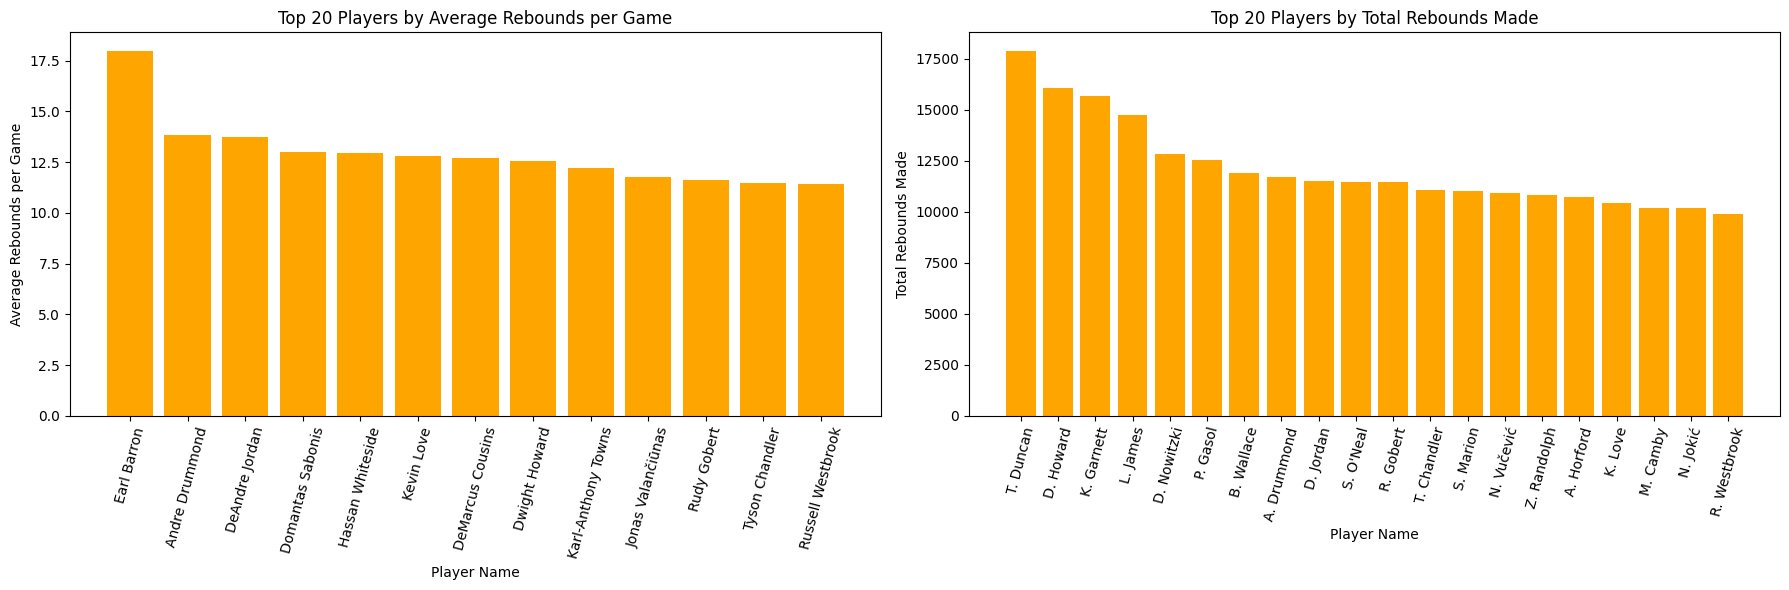

Players in both top 20 lists (aka best rebounders): {'T. Chandler', 'D. Howard', 'R. Gobert', 'K. Love', 'A. Drummond', 'D. Jordan', 'R. Westbrook'}


In [18]:
#get all rebound rows
all_rebounds_made = play_by_play[play_by_play['action_type'] == 'Rebound']

#count all the rebounds subtypes (defensive, offensive, unknown) and rank them by number of occurences
rebound_subtypes_count = all_rebounds_made['subtype'].value_counts().reset_index()
rebound_subtypes_count.columns = ['subtype', 'count']


# summ all the rebounds made by each player in the dataset
player_rebounds_total = all_rebounds_made.groupby(["player_name_i", "person_id"])["action_id"].count().reset_index()
player_rebounds_total = player_rebounds_total.sort_values(by="action_id", ascending=False).copy()

# add little name column without relying on index labels
player_rebounds_total["little_name"] = player_rebounds_total["person_id"].apply(get_player_little_name)


#subplot of top_player_rebounds_avg and player_rebounds_total head(20)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(top_player_rebounds_avg["player_name"], top_player_rebounds_avg["rebounds"], color='orange')
axes[0].set_xlabel("Player Name")
axes[0].set_ylabel("Average Rebounds per Game")
axes[0].set_title("Top 20 Players by Average Rebounds per Game")
axes[0].tick_params(axis='x', rotation=75)
axes[1].bar(player_rebounds_total["player_name_i"].head(20), player_rebounds_total["action_id"].head(20), color='orange')
axes[1].set_xlabel("Player Name")
axes[1].set_ylabel("Total Rebounds Made")
axes[1].set_title("Top 20 Players by Total Rebounds Made")
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


#get all players that are in top_player_rebounds_avg and player_rebounds_total
best_rebounder_players = set(player_rebounds_total["little_name"].head(20)).intersection(set(top_player_rebounds_avg["little_name"].head(20)))
print("Players in both top 20 lists (aka best rebounders):", best_rebounder_players)


### Best Assist Player

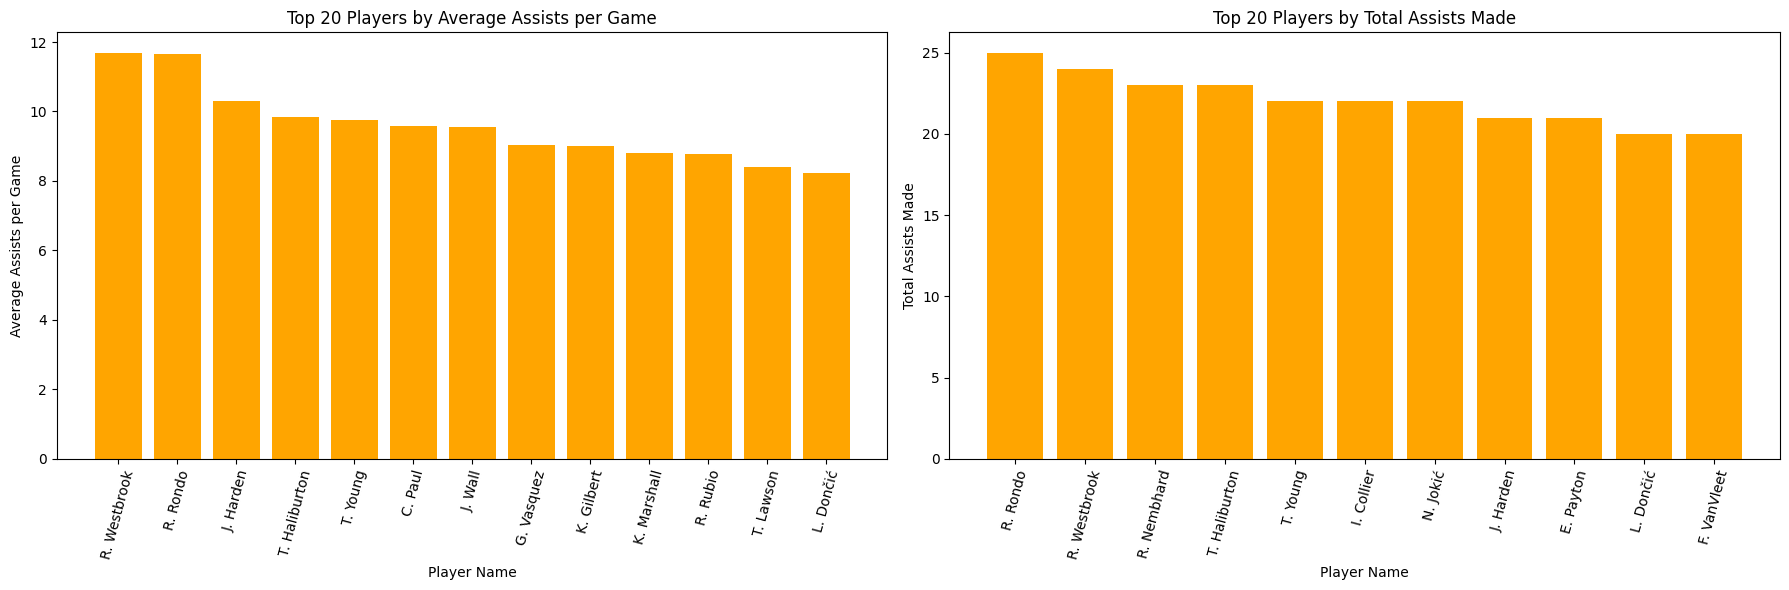

Players in both top 20 lists (aka best assisters): {'L. Dončić', 'R. Rondo', 'T. Young', 'J. Harden', 'T. Haliburton', 'R. Westbrook'}


In [36]:
# get best assist player
best_assist_player_global = player_boxscores.sort_values(by="ast", ascending=False).head(20)

best_assist_player_global["little_name"] = best_assist_player_global["player_id"].apply(get_player_little_name)


#subplot of top_player_assists_avg and player_assists_total head(20)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(top_player_assists_avg["little_name"], top_player_assists_avg["assists"], color='orange')
axes[0].set_xlabel("Player Name")
axes[0].set_ylabel("Average Assists per Game")
axes[0].set_title("Top 20 Players by Average Assists per Game")
axes[0].tick_params(axis='x', rotation=75)
axes[1].bar(best_assist_player_global["little_name"], best_assist_player_global["ast"], color='orange')
axes[1].set_xlabel("Player Name")
axes[1].set_ylabel("Total Assists Made")
axes[1].set_title("Top 20 Players by Total Assists Made")
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


#get all players that are in top_player_assists_avg and player_assists_total
best_assister_players = set(best_assist_player_global["little_name"].head(20)).intersection(set(top_player_assists_avg["little_name"].head(20)))
print("Players in both top 20 lists (aka best assisters):", best_assister_players)


## Best players

In [40]:
best_players = []

for player in best_shooter_players:
    best_players.append(player)
for player in best_rebounder_players:
    best_players.append(player)
for player in best_assister_players:
    best_players.append(player)

#clean duplicates in best_players
best_players = list(set(best_players))
display(best_players)

['T. Chandler',
 'D. Howard',
 'L. Dončić',
 'R. Rondo',
 'T. Young',
 'J. Harden',
 'L. James',
 'R. Gobert',
 'K. Durant',
 'S. Curry',
 'K. Love',
 'A. Drummond',
 'D. Jordan',
 'T. Haliburton',
 'R. Westbrook']

# Star Players (with scoring)

In [41]:
# Aggregate player stats
player_summary = (
    player_boxscores
    .groupby(['player_id','player_name'], as_index=False)
    .agg(
        games=('game_id','nunique'),
        points=('pts','mean'),
        rebounds=('reb','mean'),
        assists=('ast','mean'),
        steals=('stl','mean'),
        blocks=('blk','mean'),
        fgm=('fgm','mean'), # field goals made
        fga=('fga','mean'), # field goals attempted
        fg3m=('fg3m','mean'), # three-point field goals made
        fg3a=('fg3a','mean'), # three-point field goals attempted
        ftm=('ftm','mean'), # free throws made
        fta=('fta','mean') # free throws attempted
    )
)

player_summary['field_goal_ratio'] = player_summary['fgm'] / player_summary['fga'] # field goal percentage
player_summary['three_point_ratio'] = player_summary['fg3m'] / player_summary['fg3a'] # three-point field goal percentage
player_summary['true_shooting_ratio'] = player_summary['points'] / (2*(player_summary['fga'] + 0.44*player_summary['fta'])) # true shooting percentage

player_summary.head()

,player_id,player_name,games,points,rebounds,assists,steals,blocks,fgm,fga,fg3m,fg3a,ftm,fta,field_goal_ratio,three_point_ratio,true_shooting_ratio
0,255,Grant Hill,30,3.233333,1.766667,0.933333,0.366667,0.233333,1.333333,3.400000,0.100000,0.366667,0.466667,0.800000,0.392157,0.272727,0.430881
1,436,Juwan Howard,7,3.000000,1.142857,0.857143,0.000000,0.000000,1.428571,2.714286,0.000000,0.000000,0.142857,0.142857,0.526316,NaN,0.540123
2,467,Jason Kidd,88,5.329545,4.147727,3.102273,1.556818,0.329545,1.761364,4.931818,1.329545,3.886364,0.477273,0.568182,0.357143,0.342105,0.514254
3,703,Kurt Thomas,39,2.487179,2.282051,0.538462,0.256410,0.410256,1.153846,2.128205,0.025641,0.025641,0.153846,0.333333,0.542169,1.000000,0.546664
4,708,Kevin Garnett,225,8.711111,6.697778,1.853333,0.928889,0.622222,3.728889,7.777778,0.013333,0.137778,1.240000,1.573333,0.479429,0.096774,0.514231


In [42]:
# Star score
player_summary['star_score'] = (
    player_summary['points']*0.40 +
    player_summary['rebounds']*0.20 +
    player_summary['assists']*0.20 +
    player_summary['steals']*0.10 +
    player_summary['blocks']*0.10
)

top_stars = player_summary.sort_values('star_score', ascending=False).head(20)
top_stars[['player_name','star_score']]

,player_name,star_score
1038,Luka Dončić,15.282777
662,Joel Embiid,14.065461
80,LeBron James,13.930501
207,Kevin Durant,13.781138
285,James Harden,13.605189
680,Nikola Jokić,13.070659
575,Giannis Antetokounmpo,12.987743
288,Stephen Curry,12.971592
1036,Trae Young,12.825424
1536,Victor Wembanyama,12.704324


# Teams analysis

## Preparation

### Dictionary teams name - abreviation

In [21]:
teams_dict = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "BKN": "Brooklyn Nets",
    "CHA": "Charlotte Hornets",
    "CHI": "Chicago Bulls",
    "CLE": "Cleveland Cavaliers",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "DET": "Detroit Pistons",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "IND": "Indiana Pacers",
    "LAC": "Los Angeles Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "MIN": "Minnesota Timberwolves",
    "NOP": "New Orleans Pelicans",
    "NYK": "New York Knicks",
    "OKC": "Oklahoma City Thunder",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "SAS": "San Antonio Spurs",
    "TOR": "Toronto Raptors",
    "UTA": "Utah Jazz",
    "WAS": "Washington Wizards"
}

name_to_abbreviation = {v: k for k, v in teams_dict.items()}

In [22]:
#game_index : add team_abbreviation_home, team_abbreviation_away from teams_dict
games_index["team_abbreviation_home"] = games_index["team_name_home"].map(name_to_abbreviation)
games_index["team_abbreviation_away"] = games_index["team_name_away"].map(name_to_abbreviation)

### Aggregations from team_boxscores

In [23]:
#teams aggregate stats from team boxscores
team_agg_summary = (
        team_boxscores.groupby(["team_id", "team_abbreviation"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
                **{v: (k, "mean") for k, v in available.items()}
            )
    )
print("Aggregated Team Stats:")
display(team_agg_summary)

print()
# teams aggregate stats per season from team boxscores
team_agg_summary_per_season = (
        team_boxscores.groupby(["team_id", "team_abbreviation", "season_year"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
                **{v: (k, "mean") for k, v in available.items()}
            )
    )
print("Aggregated Team Stats per Season:")
display(team_agg_summary_per_season)

Aggregated Team Stats:


,team_id,team_abbreviation,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,1610612737,ATL,1085,109.835023,43.332719,25.323502,8.082028,4.726267,14.525346,48.331797,40.452535,87.922581,11.569585,32.495853,17.360369,22.230415,-1.129954,32.987097,10.345622
1,1610612738,BOS,1186,109.604553,44.387015,24.345700,7.478921,5.090219,13.402192,48.383642,40.123103,87.436762,12.606239,34.778246,16.752108,21.101180,4.333895,34.005902,10.381113
2,1610612739,CLE,1129,108.027458,43.221435,23.714792,7.309123,4.126661,13.985828,48.301151,39.765279,85.876882,11.419841,31.554473,17.077059,22.328609,0.511957,32.635961,10.585474
3,1610612740,NOH,52,94.884615,41.461538,21.769231,6.788462,5.634615,14.596154,48.384615,36.365385,81.000000,6.961538,18.615385,15.192308,19.615385,-4.019231,29.288462,12.173077
4,1610612740,NOP,963,110.494289,44.541018,25.105919,7.977155,5.067497,14.272066,48.321881,41.132918,88.269990,10.475597,29.461059,17.752856,23.224299,-1.396677,33.664590,10.876428
5,1610612741,CHI,1046,106.737094,44.124283,24.222753,7.473231,4.705545,14.130975,48.425430,39.858509,87.309751,10.347036,29.009560,16.673040,21.214149,-2.121415,33.792543,10.331740
6,1610612742,DAL,1050,109.115238,42.574286,23.422857,7.051429,4.460000,12.966667,48.338095,39.909524,86.469524,12.152381,33.868571,17.143810,22.346667,0.154286,33.140000,9.434286
7,1610612743,DEN,1147,111.462075,44.653880,26.292938,7.534438,4.707934,14.121186,48.366160,41.502180,87.429817,10.893636,29.946818,17.564080,22.933740,1.973845,33.526591,11.127289
8,1610612744,GSW,1159,112.471959,44.488352,27.697153,8.258844,5.229508,14.881795,48.284728,41.380500,87.853322,13.015531,34.733391,16.695427,21.310613,3.864538,34.151855,10.336497
9,1610612745,HOU,1125,110.715556,44.351111,22.722667,8.255111,4.936000,14.960000,48.306667,39.561778,87.018667,12.745778,36.425778,18.846222,25.228444,1.056889,33.106667,11.244444



Aggregated Team Stats per Season:


,team_id,team_abbreviation,season_year,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,1610612737,ATL,2012-13,63,97.206349,41.349206,23.777778,8.301587,4.539683,14.555556,48.555556,37.285714,81.619048,8.317460,23.206349,14.317460,20.396825,0.301587,31.698413,9.650794
1,1610612737,ATL,2013-14,63,98.365079,39.825397,23.777778,8.126984,3.920635,15.047619,48.396825,36.031746,81.619048,9.031746,26.190476,17.269841,21.952381,-1.142857,30.809524,9.015873
2,1610612737,ATL,2014-15,70,101.042857,41.157143,24.842857,8.757143,4.828571,14.171429,48.285714,37.642857,82.542857,9.471429,26.385714,16.285714,20.900000,3.214286,32.128571,9.028571
3,1610612737,ATL,2015-16,69,101.768116,41.710145,25.246377,9.072464,5.884058,14.869565,48.434783,38.275362,84.608696,9.695652,28.695652,15.521739,19.768116,1.884058,33.449275,8.260870
4,1610612737,ATL,2016-17,66,102.621212,43.848485,23.621212,8.060606,4.606061,15.954545,48.454545,37.712121,84.257576,8.893939,26.333333,18.303030,24.636364,-1.075758,33.545455,10.303030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,1610612766,CHA,2021-22,83,115.180723,44.530120,28.000000,8.566265,4.891566,13.265060,48.481928,42.674699,91.409639,13.927711,38.204819,15.903614,21.469880,0.084337,33.698795,10.831325
416,1610612766,CHA,2022-23,82,110.951220,44.536585,25.146341,7.731707,5.182927,14.195122,48.365854,41.280488,90.402439,10.743902,32.548780,17.646341,23.560976,-6.243902,33.548780,10.987805
417,1610612766,CHA,2023-24,82,106.585366,40.280488,24.792683,6.853659,4.524390,13.768293,48.121951,40.012195,86.987805,12.060976,34.000000,14.500000,18.439024,-10.243902,30.951220,9.329268
418,1610612766,CHA,2024-25,82,105.097561,45.195122,24.317073,7.402439,4.487805,15.500000,48.182927,38.317073,89.121951,12.987805,38.329268,15.475610,19.768293,-9.109756,32.963415,12.231707


### Aggregation from games_index

In [24]:
#teams aggregate stats per season from games_index
# "game_id","team_name_home", "team_name_away","winner", "season_year"
team_agg_summary_per_season_games_index = (
        games_index.groupby(["game_id","team_name_home", "team_name_away","winner", "season_year"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
            )
    )
print("Aggregated Team Stats per Season from games_index:")
display(team_agg_summary_per_season_games_index)

Aggregated Team Stats per Season from games_index:


,game_id,team_name_home,team_name_away,winner,season_year,games
0,20000001,New York Knicks,Philadelphia 76ers,PHI,2000-01,1
1,20000002,New Jersey Nets,Cleveland Cavaliers,CLE,2000-01,1
2,20000003,Orlando Magic,Washington Wizards,ORL,2000-01,1
3,20000004,Atlanta Hawks,Charlotte Hornets,CHH,2000-01,1
4,20000005,Toronto Raptors,Detroit Pistons,DET,2000-01,1
...,...,...,...,...,...,...
37981,52500111,Charlotte Hornets,Miami Heat,CHA,2025-26,1
37982,52500121,Phoenix Suns,Portland Trail Blazers,POR,2025-26,1
37983,52500131,LA Clippers,Golden State Warriors,GSW,2025-26,1
37984,52500201,Orlando Magic,Charlotte Hornets,ORL,2025-26,1


In [25]:
#count nb games per season from games_index
games_per_season = games_index.groupby("season_year")["game_id"].nunique().reset_index().sort_values(by="season_year", ascending=True)
print("Number of games per season from games_index:")
#display(games_per_season)

# count nb games per season per team from games_index
games_per_season_per_team = games_index.groupby(["season_year", "team_name_home"])["game_id"].nunique().reset_index().sort_values(by=["season_year", "team_name_home"], ascending=True) 
display(games_per_season_per_team)

Number of games per season from games_index:


,season_year,team_name_home,game_id
0,1996-97,Atlanta Hawks,46
1,1996-97,Boston Celtics,41
2,1996-97,Charlotte Hornets,42
3,1996-97,Chicago Bulls,52
4,1996-97,Cleveland Cavaliers,41
...,...,...,...
887,2025-26,Sacramento Kings,41
888,2025-26,San Antonio Spurs,43
889,2025-26,Toronto Raptors,44
890,2025-26,Utah Jazz,41


Team Wins:


winner
SAS    1661
LAL    1533
MIA    1519
BOS    1490
DAL    1419
HOU    1380
UTA    1379
IND    1375
PHX    1338
DEN    1317
CLE    1308
GSW    1296
POR    1294
MIL    1266
DET    1231
PHI    1216
LAC    1213
TOR    1211
CHI    1209
ATL    1193
ORL    1173
NYK    1167
MIN    1138
SAC    1117
MEM    1011
WAS    1004
OKC     941
CHA     699
NJN     591
SEA     512
BKN     511
NOP     469
NOH     357
CHH     285
VAN      86
NOK      77
Name: count, dtype: int64

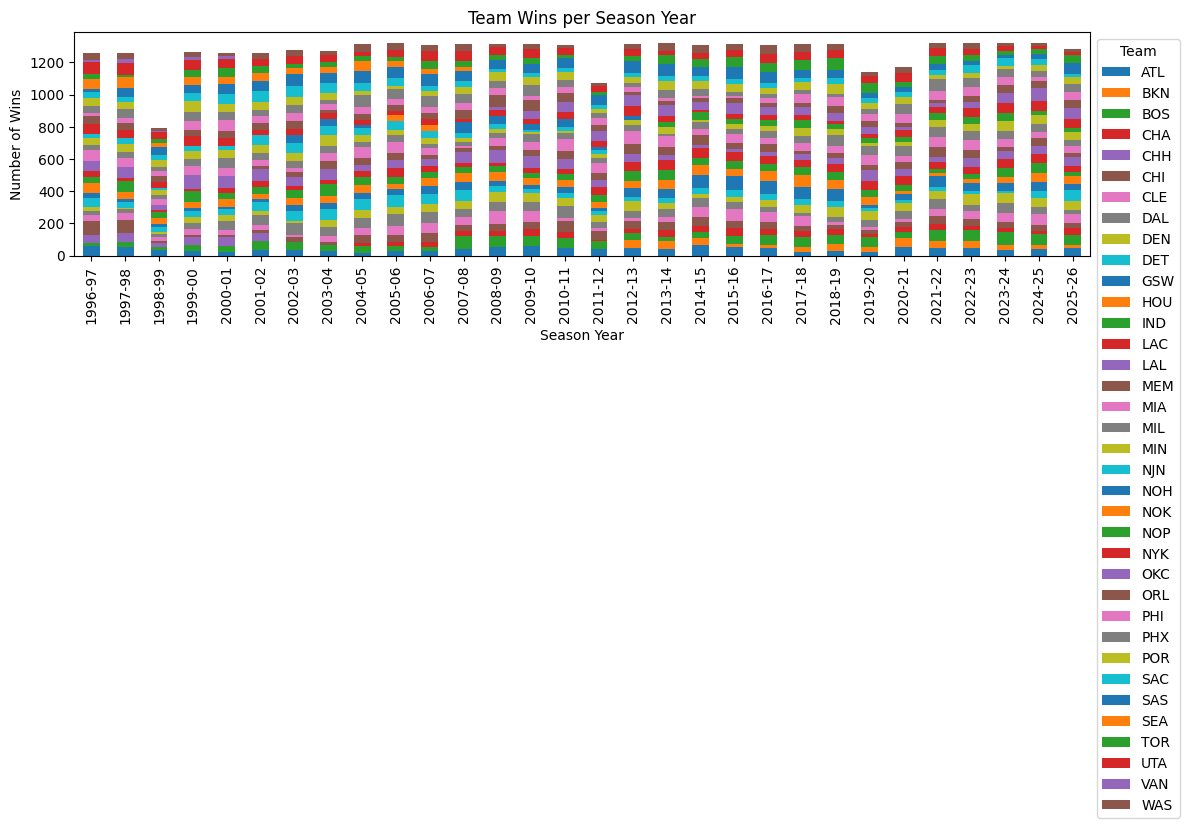

In [26]:
# get all the wins for each team from games_index 
team_wins = games_index["winner"].value_counts()
print("Team Wins:")
display(team_wins)

# bar plot of team wins per season year
team_wins_per_year = games_index.groupby(["season_year", "winner"]).size().unstack(fill_value=0)
team_wins_per_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.xlabel("Season Year")
plt.ylabel("Number of Wins")
plt.title("Team Wins per Season Year")
plt.legend(title="Team", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()